### Arquitectura F-SPDENO  ($(X_0, W) \mapsto X$)

Misma arquitectura que la tarea $W\mapsto X$, pero ahora la **condición inicial
$\chi_0$ es estocástica y distinta por muestra**. Esto activa la no linealidad en
$\chi_0$ (vía $X^3$), donde el FNO aporta sobre una regresión lineal. Flujo
(Fig. 2, Shi et al. 2026):

$$
(\chi_0, W) \;\xrightarrow{\text{Wick}}\; \eta(W)=\{\xi_\alpha\}_{|\alpha|\le M}
\;\xrightarrow{\text{FNO}}\; \{C_k(x)\}
\;\xrightarrow{\text{Haar}}\; \hat u(t,x)=\sum_k C_k(x)\,\phi_k(t)
$$

**1. Features de Wick:** $\eta(W)$, idéntico a la tarea anterior (escalares por muestra).

**2. FNO:** recibe como canales $\chi_0(x)$ **real de cada muestra** (no cero), la
grilla $x$, y las features $\eta(W)$; produce los coeficientes $C_k(x)$.

**3. Reconstrucción:** $\hat u(t,x)=\sum_k C_k(x)\,\phi_k(t)$, base de Haar fija.

Diferencia con $W\mapsto X$: el canal $\chi_0$ ya no es cero, sino la condición
inicial de cada trayectoria (se obtiene de $X[:,0,:]$). Métrica: error $L^2$
relativo. Referencia (Salvi, Table 1, $(u_0,\xi)\mapsto u$): NSPDE $0.049$.


In [2]:
from itertools import count
from math import factorial
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from numpy.polynomial.hermite_e import hermeval  # Hermite probabilista h_k (He)

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"  # GPU si hay (T4 colab)

# ---------------- CONFIG UNICA ----------------
S = 8  # numero modos ESPACIALES de Wick (KL).
TM = 3  # numero modos TEMPORALES e_j de las coordenadas del ruido
M = 2  # orden de Hermite / caos.  #features = C(S*TM + M, M)
K_HAAR = 16  # numero de funciones de Haar phi_k para los propagadores
WIDTH = 64  # ancho latente del FNO
MODES = 16  # numero de modos de Fourier retenidos por capa espectral
N_LAYERS = 6  # numero de capas de Fourier
EPOCHS = 200
BS = 64
LR = 1e-3

print("device:", device)
print(
    f"S={S} TM={TM} M={M} K_HAAR={K_HAAR} WIDTH={WIDTH} MODES={MODES} N_LAYERS={N_LAYERS}"
)

device: cuda
S=8 TM=3 M=2 K_HAAR=16 WIDTH=64 MODES=16 N_LAYERS=6


In [3]:
# ============ Carga de datos:  W (Q-Browniano), X (solucion), chi0 ============
data = np.load("phi41_train_X0Wmap.npz")
Wtr, Xtr = data["W_train"], data["X_train"]  # train: ruido acumulado / solucion u(t,x)
Wte, Xte = data["W_test"], data["X_test"]  # test
dx, dt = float(data["dx"]), float(data["dt"])
T, sigma = float(data["T"]), float(data["sigma"])
L = 1.0

N, Ntp1, Nx = Wtr.shape
Nt = Ntp1 - 1
chi0_tr = Xtr[:, 0, :].astype(np.float32)  # CI por muestra (X en t=0)
chi0_te = Xte[:, 0, :].astype(np.float32)
x = np.arange(Nx) * dx  # grilla espacial (toro [0,1])
tinc = np.arange(Nt) * dt  # extremo izq. de cada incremento temporal
ssol = np.arange(Ntp1) / Nt  # tiempo normalizado [0,1] (Ntp1 puntos)
print(f"N={N} Nt={Nt} Nx={Nx} dt={dt} T={T} sigma={sigma}")
print("Wtr:", Wtr.shape, "| Xtr:", Xtr.shape)

N=1000 Nt=50 Nx=129 dt=0.001 T=0.05 sigma=0.1
Wtr: (1000, 51, 129) | Xtr: (1000, 51, 129)


In [4]:
# ============ Features de Wick:  W  ->  eta(W) = {xi_alpha}_{|alpha|<=M} ============
# Def.1  coordenadas gaussianas:  xi_{m,j} = int_0^T e_j(s) dbeta^{(m)}_s
#   m = modo espacial (eigenfn KL: phi_m(x)=sqrt(2/L) sin(m pi x/L))
#   j = modo temporal (base ortonormal {e_j} de L^2([0,T]))
# Def.2  monomio de Wick:  xi_alpha = (1/sqrt(alpha!)) prod_{m,j} h_{alpha_{m,j}}(xi_{m,j})


def multi_indices(D, M):
    """Multi-indices alpha=(a_1..a_D), a_d>=0, sum<=M.  alpha=(0..0) -> xi_0=1."""
    res = []

    def rec(pref, rem):
        if len(pref) == D:
            res.append(tuple(pref))
            return
        for v in range(rem + 1):
            rec(pref + [v], rem - v)

    rec([], M)
    return res


def hermite(k, xv):  # h_k probabilista (Hermite)
    c = np.zeros(k + 1)
    c[k] = 1.0
    return hermeval(xv, c)


def wick(xi_flat, alphas, M):  # (N,#alphas) monomios normalizados
    N_, D = xi_flat.shape
    H = np.empty((M + 1, N_, D))  # H[k,i,d] = h_k(xi_flat[i,d])
    for k in range(M + 1):
        H[k] = hermite(k, xi_flat)
    out = np.empty((N_, len(alphas)))
    for idx, a in enumerate(alphas):
        val = np.ones(N_)
        af = 1
        for d, ad in enumerate(a):
            if ad > 0:
                val = val * H[ad, :, d]
                af *= factorial(ad)
        out[:, idx] = val / np.sqrt(af)
    return out


def construir_features_wick(W, S, TM, M):
    """W:(N,Nt+1,Nx) ruido acumulado -> (Xi:(N,#feats), alphas)."""
    N_ = W.shape[0]
    dW = np.diff(W, axis=1)  # incrementos (N,Nt,Nx)
    # (1a) proyeccion ESPACIAL sobre phi_m -> incrementos modales dbeta^{(m)}
    m_sp = np.arange(1, S + 1)
    phi = np.sqrt(2.0 / L) * np.sin(np.outer(m_sp, np.pi * x / L))  # (S,Nx)
    dbeta = np.einsum("ink,mk->inm", dW, phi) * dx / sigma  # (N,Nt,S)
    # (1b) base TEMPORAL ortonormal {e_j}  (Fourier + QR con peso dt)
    # TODO[fuente]: el paper usa e_j ligada a la reconstruccion del browniano
    #   (Lemma 1: G_j(t)=int_0^t e_j). Aqui usamos Fourier+QR. Verificar contra fuente.
    raw = [np.ones_like(tinc)]
    for k in count(1):
        if len(raw) >= TM:
            break
        raw.append(np.cos(2 * np.pi * k * tinc / T))
        if len(raw) < TM:
            raw.append(np.sin(2 * np.pi * k * tinc / T))
    Q, _ = np.linalg.qr(np.stack(raw, 1) * np.sqrt(dt))
    E = Q / np.sqrt(dt)  # (Nt,TM), E^T E dt = I
    # (1c) coordenadas gaussianas + (2) monomios de Wick
    xi_flat = np.einsum("nj,inm->imj", E, dbeta).reshape(N_, S * TM)
    alphas = multi_indices(S * TM, M)
    return wick(xi_flat, alphas, M), alphas


Ftr, alphas = construir_features_wick(Wtr, S, TM, M)
Fte, _ = construir_features_wick(Wte, S, TM, M)
mu, sd = Ftr.mean(0), Ftr.std(0) + 1e-8  # estandarizar con stats de train
Ftr, Fte = (Ftr - mu) / sd, (Fte - mu) / sd
P = Ftr.shape[1]
print(f"#features de Wick = C(S*TM+M, M) = {P}   (col 0 = xi_0 = 1)")
print(f"features con sd~0 (revisar): {(sd < 1e-6).sum()}")

#features de Wick = C(S*TM+M, M) = 325   (col 0 = xi_0 = 1)
features con sd~0 (revisar): 1


In [5]:
# ============ Base temporal de Haar {phi_k} y proyeccion de propagadores ============
# u(t,x) = sum_k C_k(x) phi_k(t).  El FNO produce los C_k(x); phi_k(t) es fija.
# OJO: esta base {phi_k} (propagadores) es DISTINTA de {e_j} (coordenadas del ruido).


def haar_funcs(K, s):
    funcs = [np.ones_like(s)]
    level = 0
    while len(funcs) < K:
        for m in range(2**level):
            if len(funcs) >= K:
                break
            a = m / 2**level
            b = (m + 1) / 2**level
            mid = (a + b) / 2
            psi = np.zeros_like(s)
            psi[(s >= a) & (s < mid)] = 1.0
            psi[(s >= mid) & (s < b)] = -1.0
            funcs.append(psi)
        level += 1
    return np.stack(funcs[:K], axis=1)


def haar_ortonormal(K, s):
    Phi = haar_funcs(K, s)
    Phi = Phi[:, np.linalg.norm(Phi, axis=0) > 1e-12]
    Q, _ = np.linalg.qr(Phi)
    return Q  # Q^T Q = I


Qh = haar_ortonormal(K_HAAR, ssol)  # (Ntp1, K)
Kout = Qh.shape[1]
# E_K: piso de error por truncar la base temporal (Prop.5: E_K ~ K^{-s})
Cgt = np.einsum("tk,ntx->nkx", Qh, Xtr)
Xrec = np.einsum("tk,nkx->ntx", Qh, Cgt)
E_K = (
    np.linalg.norm((Xtr - Xrec).reshape(N, -1), axis=1)
    / np.linalg.norm(Xtr.reshape(N, -1), axis=1)
).mean()
print(f"K_HAAR={K_HAAR} (rango {Kout})  ->  E_K = {E_K:.3e}  (piso de error)")

K_HAAR=16 (rango 16)  ->  E_K = 4.373e-02  (piso de error)


In [6]:
# ============ Tensores de entrada del FNO (B, Nx, canales) ============
# canal 0   : chi0(x)  CONDICION INICIAL REAL por muestra (tarea (X0,W)->X)
# canal 1   : x        (grilla; le da al FNO informacion de posicion)
# canal 2.. : eta(W)   (features de Wick, ESCALARES -> repetidas/constantes en x)
def construir_entrada(Fmat, chi0):
    n = len(Fmat)
    chi0 = chi0[:, :, None].astype(np.float32)                       # (n, Nx, 1)
    grid = np.repeat(x.astype(np.float32)[None, :, None], n, axis=0)
    feat = np.repeat(Fmat[:, None, :].astype(np.float32), Nx, axis=1)
    return np.concatenate([chi0, grid, feat], axis=-1)              # (n, Nx, 2+P)


Xin_tr = torch.tensor(construir_entrada(Ftr, chi0_tr)).to(device)
Xin_te = torch.tensor(construir_entrada(Fte, chi0_te)).to(device)
Y_tr = torch.tensor(Xtr.astype(np.float32)).to(device)              # objetivo u(t,x)
Y_te = torch.tensor(Xte.astype(np.float32)).to(device)
Qt = torch.tensor(Qh.astype(np.float32)).to(device)                # base de Haar
in_c = Xin_tr.shape[-1]
print(
    f"entrada FNO: {tuple(Xin_tr.shape)}  (in_c = 1 chi0 + 1 grilla + {P} Wick = {in_c})"
)


entrada FNO: (1000, 129, 327)  (in_c = 1 chi0 + 1 grilla + 325 Wick = 327)


In [7]:
# ============ Backbone FNO 1D (Li et al. 2020) ============
class SpectralConv1d(nn.Module):
    """Convolucion espectral: FFT -> x pesos en modos bajos -> IFFT (filtro pasa-bajos)."""

    def __init__(self, in_c, out_c, modes):
        super().__init__()
        self.modes = modes
        scale = 1.0 / (in_c * out_c)
        self.weight = nn.Parameter(
            scale * torch.rand(in_c, out_c, modes, dtype=torch.cfloat)
        )

    def forward(self, x):  # x: (B,C,Nx)
        n = x.shape[-1]
        xft = torch.fft.rfft(x)
        # device=x.device  <- imprescindible en GPU (si no, revienta el forward)
        out = torch.zeros(
            x.shape[0],
            self.weight.shape[1],
            n // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )
        m = min(self.modes, xft.shape[-1])
        out[..., :m] = torch.einsum("bim,iom->bom", xft[..., :m], self.weight[..., :m])
        return torch.fft.irfft(out, n=n)


class FNO1d(nn.Module):
    """lifting -> n_layers capas de Fourier (rama global + rama local 1x1) -> projection."""

    def __init__(self, in_c, out_c, width=64, modes=16, n_layers=6):
        super().__init__()
        self.fc0 = nn.Linear(in_c, width)  # lifting (puntual)
        self.spec = nn.ModuleList(
            [SpectralConv1d(width, width, modes) for _ in range(n_layers)]
        )
        self.pw = nn.ModuleList([nn.Conv1d(width, width, 1) for _ in range(n_layers)])
        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, out_c)

    def forward(self, x):  # x: (B,Nx,in_c)
        x = self.fc0(x).permute(0, 2, 1)  # -> (B,width,Nx)
        for sp, w in zip(self.spec, self.pw):
            x = F.gelu(sp(x) + w(x))  # global + local
        x = x.permute(0, 2, 1)  # -> (B,Nx,width)
        return self.fc2(F.gelu(self.fc1(x)))  # (B,Nx,out_c) = C_k(x)


def reconstruir(C):  # u = sum_k C_k(x) phi_k(t)
    return torch.einsum("bxk,tk->btx", C, Qt)  # (B,Nx,K) -> (B,Ntp1,Nx)


def rel_l2(pred, Y):  # metrica del paper
    num = torch.linalg.norm((pred - Y).reshape(len(Y), -1), dim=1)
    den = torch.linalg.norm(Y.reshape(len(Y), -1), dim=1)
    return (num / den).mean()


net = FNO1d(in_c, Kout, WIDTH, MODES, N_LAYERS).to(device)
print(
    f"FNO: {N_LAYERS} capas, ancho {WIDTH}, {MODES} modos -> "
    f"{sum(p.numel() for p in net.parameters()):,} parametros"
)

FNO: 6 capas, ancho 64, 16 modos -> 449,552 parametros


**Obs: (para ground truth Wmap (sin c.i. variable) y N=1000)**
- GPU T4: 30seg aprox.
- CPU   : 6min 11seg

epoca   0: train_error=0.5384  test_error=0.5463  lr=1.0e-03
epoca  20: train_error=0.1017  test_error=0.1727  lr=1.0e-03
epoca  40: train_error=0.0840  test_error=0.1595  lr=1.0e-03
epoca  60: train_error=0.0770  test_error=0.1533  lr=1.0e-03
epoca  80: train_error=0.0726  test_error=0.1513  lr=1.0e-03
epoca 100: train_error=0.0687  test_error=0.1501  lr=1.0e-03
epoca 120: train_error=0.0660  test_error=0.1500  lr=1.0e-04
epoca 140: train_error=0.0656  test_error=0.1502  lr=1.0e-05
epoca 160: train_error=0.0656  test_error=0.1502  lr=1.0e-06
epoca 180: train_error=0.0656  test_error=0.1502  lr=1.0e-08
epoca 199: train_error=0.0656  test_error=0.1502  lr=1.0e-08

MEJOR test = 0.1488


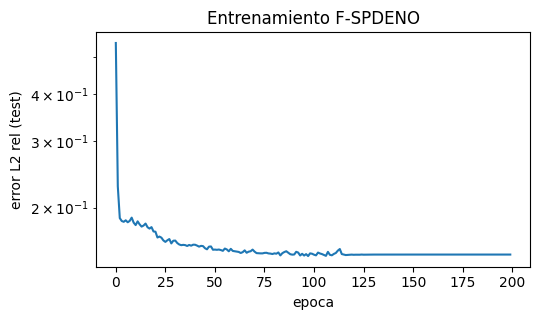

In [8]:
# ============ Entrenamiento (Apendice F.1) + guardado del MEJOR modelo ============
opt = torch.optim.Adam(net.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.1, patience=15)
best, hist = float("inf"), []
for ep in range(EPOCHS):
    net.train()
    perm = torch.randperm(len(Xin_tr))
    for i in range(0, len(perm), BS):
        idx = perm[i : i + BS]
        opt.zero_grad()
        loss = rel_l2(reconstruir(net(Xin_tr[idx])), Y_tr[idx])
        loss.backward()
        opt.step()
    net.eval()
    with torch.no_grad():
        e_te = rel_l2(reconstruir(net(Xin_te)), Y_te).item()
    sched.step(e_te)
    hist.append(e_te)
    if e_te < best:  # <- reportar el mejor, no el ultimo
        best = e_te
        torch.save(net.state_dict(), "best.pt")
    if ep % 20 == 0 or ep == EPOCHS - 1:
        with torch.no_grad():
            e_tr = rel_l2(reconstruir(net(Xin_tr)), Y_tr).item()
        print(
            f"epoca {ep:>3}: train_error={e_tr:.4f}  test_error={e_te:.4f}  "
            f"lr={opt.param_groups[0]['lr']:.1e}"
        )
print(f"\nMEJOR test = {best:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 3.3))
ax.plot(hist)
ax.set_yscale("log")
ax.set_xlabel("epoca")
ax.set_ylabel("error L2 rel (test)")
ax.set_title("Entrenamiento F-SPDENO")
plt.tight_layout()
plt.show()

Error L2 relativo de TEST ((X_0, W)->X): 0.1488
Referencia paper (Table 1, F-SPDENO, N=1000, (X_0, W)->X): 0.015


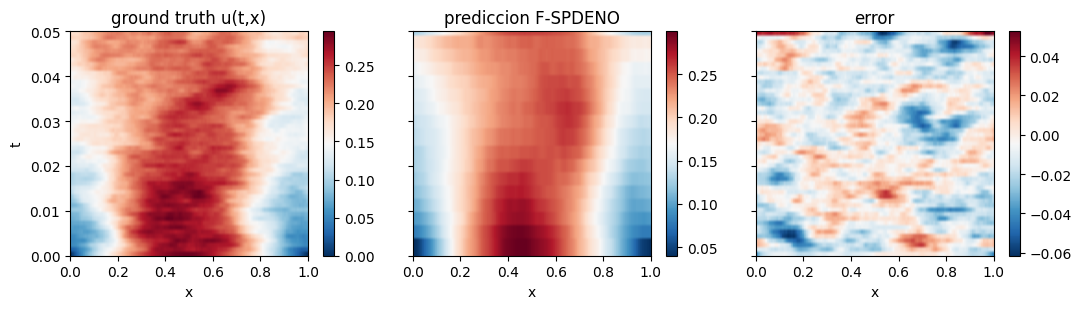

In [13]:
# ============ Evaluacion (mejor modelo) + comparacion Table 1 ============
net.load_state_dict(torch.load("best.pt"))  # <- usar el mejor checkpoint
net.eval()
with torch.no_grad():
    pred_te = reconstruir(net(Xin_te))
err = rel_l2(pred_te, Y_te).item()
print(f"Error L2 relativo de TEST ((X_0, W)->X): {err:.4f}")
print("Referencia paper (Table 1, F-SPDENO, N=1000, (X_0, W)->X): 0.015")

i0, ext = 0, [0, L, 0, T]
gt, pr = (
    Y_te[i0].cpu().numpy(),
    pred_te[i0].cpu().numpy(),
)  # .cpu() para graficar desde GPU
fig, axs = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, dat, ttl in zip(
    axs, [gt, pr, gt - pr], ["ground truth u(t,x)", "prediccion F-SPDENO", "error"]
):
    im = ax.imshow(dat, aspect="auto", origin="lower", extent=ext, cmap="RdBu_r")
    ax.set_xlabel("x")
    ax.set_title(ttl)
    fig.colorbar(im, ax=ax)
axs[0].set_ylabel("t")
plt.tight_layout()
plt.show()

**Obs:** Cálculos de K para gráfico usar GPU T4, tiempo en CPU muy grande (4-5min por K aprox)

K= 16: mejor test = 0.1373
K= 32: mejor test = 0.1535
K= 64: mejor test = 0.1420
K= 96: mejor test = 0.1505


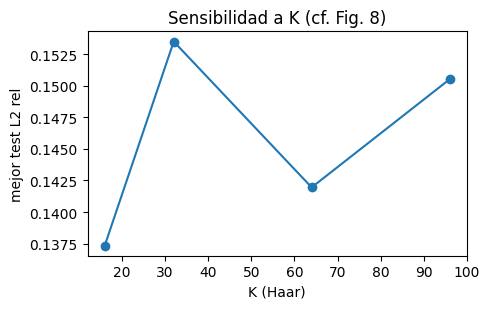

In [10]:
# ============ (opcional) Barrido en K de Haar -> sensibilidad (Fig. 8) ============
def correr(K_haar, epochs=120):
    Qh_ = haar_ortonormal(K_haar, ssol)
    Qt_ = torch.tensor(Qh_.astype(np.float32)).to(device)
    Kout_ = Qh_.shape[1]
    net_ = FNO1d(in_c, Kout_, WIDTH, MODES, N_LAYERS).to(device)
    opt_ = torch.optim.Adam(net_.parameters(), lr=LR)
    sch_ = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_, factor=0.1, patience=15)
    rec = lambda C: torch.einsum("bxk,tk->btx", C, Qt_)
    best_ = float("inf")
    for ep in range(epochs):
        net_.train()
        perm = torch.randperm(len(Xin_tr))
        for i in range(0, len(perm), BS):
            idx = perm[i : i + BS]
            opt_.zero_grad()
            l = rel_l2(rec(net_(Xin_tr[idx])), Y_tr[idx])
            l.backward()
            opt_.step()
        net_.eval()
        with torch.no_grad():
            e = rel_l2(rec(net_(Xin_te)), Y_te).item()
        sch_.step(e)
        best_ = min(best_, e)
    return best_


Ks = [16, 32, 64, 96]  # valores test del paper.
errs = []
for K in Ks:
    e = correr(K)
    errs.append(e)
    print(f"K={K:>3}: mejor test = {e:.4f}")

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(Ks, errs, "o-")
ax.set_xlabel("K (Haar)")
ax.set_ylabel("mejor test L2 rel")
ax.set_title("Sensibilidad a K (cf. Fig. 8)")
plt.tight_layout()
plt.show()